## Imports necesarios

In [45]:
import sys
sys.path.append(r"C:\Users\david\Documents\M5 challenge\etl")
 
import pandas as pd
import numpy as np

from load import cargar_datasets
 
df_sales_validation, df_calendar, df_sell = cargar_datasets()
 

Los Datasets han sido cargados


In [47]:
df_sales_valid_sample = df_sales_validation.head().to_csv(r"C:\Users\david\Documents\M5 challenge\sales_validation_sample.csv", index=False)  

In [48]:
df_calendar_sample = df_calendar.head().to_csv(r"C:\Users\david\Documents\M5 challenge\calendar_sample.csv", index=False)

In [49]:
df_sell_sample = df_sell.head().to_csv(r"C:\Users\david\Documents\M5 challenge\sell_sample.csv", index=False)

### Duplicados

In [8]:
print("Duplicados en sales_validation :", df_sales_validation.duplicated().sum())
print("Duplicados en calendar:", df_calendar.duplicated().sum())
print("Duplicados en sell_prices: ", df_sell.duplicated().sum())

Duplicados en sales_validation : 0
Duplicados en calendar: 0
Duplicados en sell_prices:  0


### Nulos

In [14]:
columnas_id = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"] # Solo son de interes las colunmas de ids
 
print("Nulos en columnas de id (sales):")
print(df_sales_validation[columnas_id].isnull().sum())
 
print("\n\nNulos en calendar:")
print(df_calendar.isnull().sum())
 
print("\n\nNulos en sell_prices:")
print(df_sell.isnull().sum())
 

Nulos en columnas de id (sales):
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
dtype: int64


Nulos en calendar:
date            0
wm_yr_wk        0
weekday         0
d               0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
dtype: int64


Nulos en sell_prices:
store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64


### Valores unicos

In [16]:
print("Valores unicos por columna de ids:\n")
for col in columnas_id:
    print(f"  {col:<12} : {df_sales_validation[col].nunique():>5} valores unicos")
 

Valores unicos por columna de ids:

  id           : 30490 valores unicos
  item_id      :  3049 valores unicos
  dept_id      :     7 valores unicos
  cat_id       :     3 valores unicos
  store_id     :    10 valores unicos
  state_id     :     3 valores unicos


In [25]:
print("Categoras :", df_sales_validation["cat_id"].cat.categories.tolist())
print("Estados:", df_sales_validation["state_id"].cat.categories.tolist())
print("Tiendas:", df_sales_validation["store_id"].cat.categories.tolist())
print("Departamentos:", df_sales_validation["dept_id"].cat.categories.tolist())

Categoras : ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Estados: ['CA', 'TX', 'WI']
Tiendas: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Departamentos: ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']


### Estadisticas descriptiva

In [30]:
columnas_dias = [col for col in df_sales_validation.columns if col.startswith("d_")]
 
df_sales_validation["total_unidades"] = df_sales_validation[columnas_dias].sum(axis=1)
df_sales_validation["media_diaria"]   = df_sales_validation[columnas_dias].mean(axis=1).round(2)
df_sales_validation["max_dia"]        = df_sales_validation[columnas_dias].max(axis=1)
 
print("Estadística descriptiva — unidades totales por SKU:\n")
print(df_sales_validation["total_unidades"].describe().round(2))

Estadística descriptiva — unidades totales por SKU:

count     30490.00
mean       2154.65
std        5217.23
min          10.00
25%         355.00
50%         848.00
75%        2031.75
max      250502.00
Name: total_unidades, dtype: float64


In [31]:
# ── CELDA 12 — unidades totales por categoría ─────────────────────────────────
 
total_general = df_sales_validation["total_unidades"].sum()
 
resumen_cat = (
    df_sales_validation
    .groupby("cat_id", observed=True)["total_unidades"]
    .agg(["sum", "mean", "median", "std"])
    .rename(columns={"sum": "total", "mean": "media", "median": "mediana", "std": "desv_std"})
    .round(2)
)
resumen_cat["% del total"] = (resumen_cat["total"] / total_general * 100).round(1)
 
print("Resumen de unidades por categoría:\n")
print(resumen_cat)

Resumen de unidades por categoría:

              total    media  mediana  desv_std  % del total
cat_id                                                      
FOODS      45089939  3137.78   1351.0   7063.49         68.6
HOBBIES     6124800  1084.04    447.5   1985.38          9.3
HOUSEHOLD  14480670  1383.06    624.0   2474.78         22.0


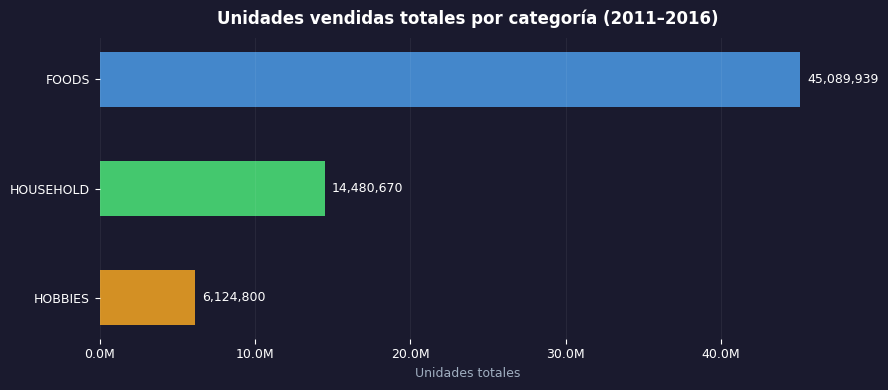

In [32]:
# ── CELDA 13 — gráfica: unidades totales por categoría ───────────────────────
 
totales_cat = df_sales_validation.groupby("cat_id", observed=True)["total_unidades"].sum().sort_values()
 
fig, ax = plt.subplots(figsize=(9, 4), facecolor=PALETA["fondo"])
ax.set_facecolor(PALETA["fondo"])
 
colores_barras = [PALETA.get(str(c), "#A0AEC0") for c in totales_cat.index]
 
barras = ax.barh(
    totales_cat.index.astype(str),
    totales_cat.values,
    color  = colores_barras,
    height = 0.5,
    alpha  = 0.85
)
 
# Etiqueta de valor en cada barra
for barra, val in zip(barras, totales_cat.values):
    ax.text(
        val + totales_cat.max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{val:,.0f}",
        va="center", fontsize=9, color="white"
    )
 
ax.set_title("Unidades vendidas totales por categoría (2011–2016)", fontsize=12, fontweight="bold", color="white", pad=10)
ax.set_xlabel("Unidades totales", color=PALETA["neutro"], fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.tick_params(colors="white", labelsize=9)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(axis="x", color="white", alpha=0.06, linewidth=0.8)
 
plt.tight_layout()
plt.show()
 

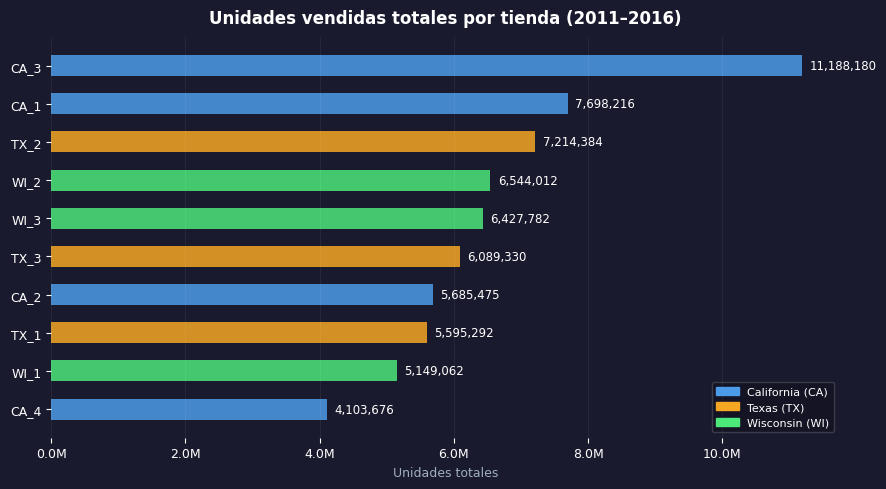

In [33]:
# ── CELDA 14 — gráfica: unidades totales por tienda ──────────────────────────
 
totales_tienda = df_sales_validation.groupby("store_id", observed=True)["total_unidades"].sum().sort_values()
 
fig, ax = plt.subplots(figsize=(9, 5), facecolor=PALETA["fondo"])
ax.set_facecolor(PALETA["fondo"])
 
colores_tienda = [
    PALETA["FOODS"]     if "CA" in str(s) else
    PALETA["HOBBIES"]   if "TX" in str(s) else
    PALETA["HOUSEHOLD"] for s in totales_tienda.index
]
 
barras = ax.barh(
    totales_tienda.index.astype(str),
    totales_tienda.values,
    color  = colores_tienda,
    height = 0.55,
    alpha  = 0.85
)
 
for barra, val in zip(barras, totales_tienda.values):
    ax.text(
        val + totales_tienda.max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f"{val:,.0f}",
        va="center", fontsize=8.5, color="white"
    )
 
# Leyenda de estados
leyenda = [
    plt.Rectangle((0,0),1,1, color=PALETA["FOODS"],     label="California (CA)"),
    plt.Rectangle((0,0),1,1, color=PALETA["HOBBIES"],   label="Texas (TX)"),
    plt.Rectangle((0,0),1,1, color=PALETA["HOUSEHOLD"], label="Wisconsin (WI)"),
]
ax.legend(handles=leyenda, fontsize=8, framealpha=0.2, loc="lower right")
 
ax.set_title("Unidades vendidas totales por tienda (2011–2016)", fontsize=12, fontweight="bold", color="white", pad=10)
ax.set_xlabel("Unidades totales", color=PALETA["neutro"], fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.tick_params(colors="white", labelsize=9)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(axis="x", color="white", alpha=0.06, linewidth=0.8)
 
plt.tight_layout()
plt.show()
 

### Valores atipicos

In [38]:
Q1  = df_sell["sell_price"].quantile(0.25)
Q3  = df_sell["sell_price"].quantile(0.75)
IQR = Q3 - Q1
 
limite_superior = Q3 + 1.5 * IQR
mediana         = df_sell["sell_price"].median()
percentil_99    = df_sell["sell_price"].quantile(0.99)
n_outliers      = (df_sell["sell_price"] > limite_superior).sum()
 
print(f"Q1 / Q3              : ${Q1:.2f}  /  ${Q3:.2f}")
print(f"IQR                  : ${IQR:.2f}")
print(f"Límite superior IQR  : ${limite_superior:.2f}")
print(f"Mediana              : ${mediana:.2f}")
print(f"Outliers detectados  : {n_outliers:,}  ({n_outliers/len(df_sell)*100:.2f}% del total)")

Q1 / Q3              : $2.18  /  $5.84
IQR                  : $3.66
Límite superior IQR  : $11.33
Mediana              : $3.47
Outliers detectados  : 303,640  (4.44% del total)


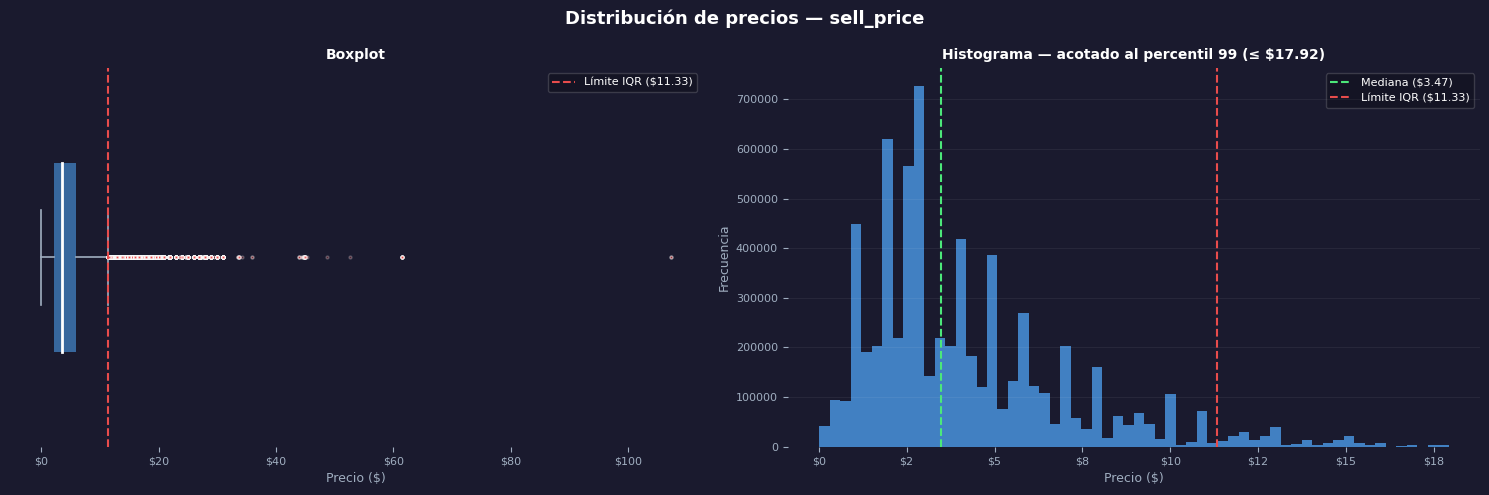

In [39]:
# ── CELDA 20 — boxplot + histograma de precios ────────────────────────────────
 
precios_acotado = df_sell[df_sell["sell_price"] <= percentil_99]["sell_price"]
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor=PALETA["fondo"])
fig.suptitle("Distribución de precios — sell_price", fontsize=13, fontweight="bold", color="white")
 
# Boxplot
ax = axes[0]
ax.set_facecolor(PALETA["fondo"])
bp = ax.boxplot(
    df_sell["sell_price"], vert=False, patch_artist=True, widths=0.5,
    flierprops  = dict(marker="o", markerfacecolor=PALETA["acento"], markersize=2, alpha=0.25, linestyle="none"),
    boxprops    = dict(facecolor=PALETA["FOODS"], alpha=0.6, linewidth=0),
    medianprops = dict(color="white", linewidth=2),
    whiskerprops= dict(color=PALETA["neutro"], linewidth=1.2),
    capprops    = dict(color=PALETA["neutro"], linewidth=1.2),
)
ax.axvline(limite_superior, color=PALETA["acento"], linewidth=1.5, linestyle="--",
           label=f"Límite IQR (${limite_superior:.2f})")
ax.set_title("Boxplot", color="white", fontsize=10, fontweight="bold")
ax.set_xlabel("Precio ($)", color=PALETA["neutro"], fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax.tick_params(colors=PALETA["neutro"], labelsize=8)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.legend(fontsize=8, framealpha=0.2)
ax.set_yticks([])
 
# Histograma acotado al percentil 99
ax = axes[1]
ax.set_facecolor(PALETA["fondo"])
ax.hist(precios_acotado, bins=60, color=PALETA["FOODS"], alpha=0.8, edgecolor="none")
ax.axvline(mediana,         color=PALETA["HOUSEHOLD"], linewidth=1.5, linestyle="--", label=f"Mediana (${mediana:.2f})")
ax.axvline(limite_superior, color=PALETA["acento"],    linewidth=1.5, linestyle="--", label=f"Límite IQR (${limite_superior:.2f})")
ax.set_title(f"Histograma — acotado al percentil 99 (≤ ${percentil_99:.2f})", color="white", fontsize=10, fontweight="bold")
ax.set_xlabel("Precio ($)", color=PALETA["neutro"], fontsize=9)
ax.set_ylabel("Frecuencia", color=PALETA["neutro"], fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax.tick_params(colors=PALETA["neutro"], labelsize=8)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(axis="y", color="white", alpha=0.06)
ax.legend(fontsize=8, framealpha=0.2)
 
plt.tight_layout()
plt.show()

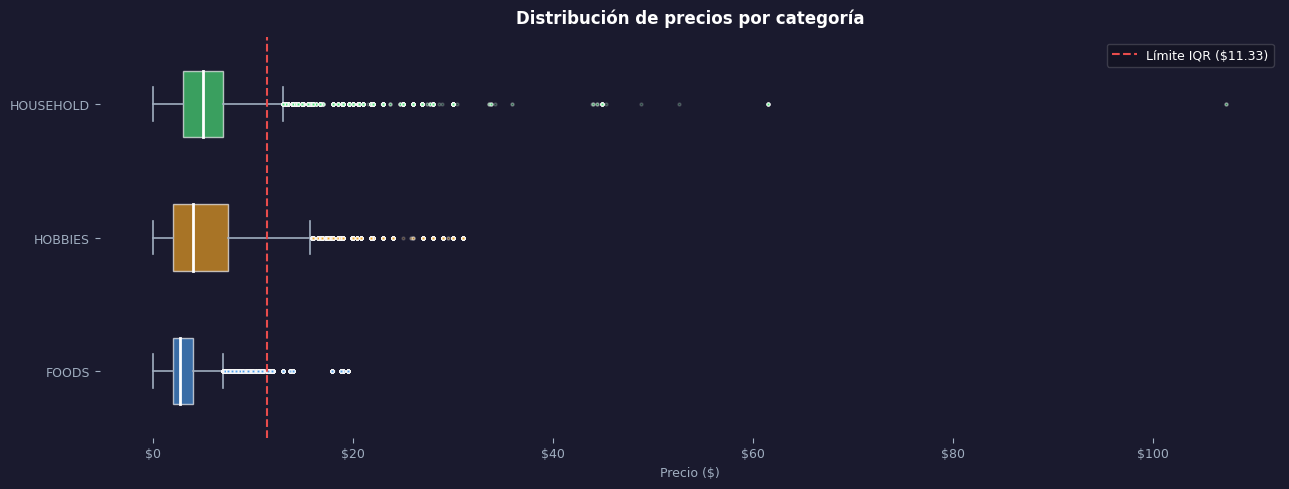

In [40]:
# ── CELDA 21 — boxplot de precios por categoría ───────────────────────────────
 
df_sell["cat_id"] = df_sell["item_id"].astype(str).str.split("_").str[0]
 
categorias   = ["FOODS", "HOBBIES", "HOUSEHOLD"]
colores_cat  = [PALETA["FOODS"], PALETA["HOBBIES"], PALETA["HOUSEHOLD"]]
datos_por_cat = [df_sell[df_sell["cat_id"] == cat]["sell_price"].values for cat in categorias]
 
fig, ax = plt.subplots(figsize=(13, 5), facecolor=PALETA["fondo"])
ax.set_facecolor(PALETA["fondo"])
 
bp = ax.boxplot(
    datos_por_cat, vert=False, patch_artist=True, widths=0.5,
    flierprops  = dict(marker="o", markersize=2, alpha=0.2, linestyle="none"),
    medianprops = dict(color="white", linewidth=2),
    whiskerprops= dict(color=PALETA["neutro"], linewidth=1.2),
    capprops    = dict(color=PALETA["neutro"], linewidth=1.2),
)
for patch, color, flier in zip(bp["boxes"], colores_cat, bp["fliers"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
    flier.set_markerfacecolor(color)
 
ax.axvline(limite_superior, color=PALETA["acento"], linewidth=1.5, linestyle="--",
           label=f"Límite IQR (${limite_superior:.2f})")
ax.set_title("Distribución de precios por categoría", fontsize=12, fontweight="bold", color="white", pad=10)
ax.set_xlabel("Precio ($)", color=PALETA["neutro"], fontsize=9)
ax.set_yticklabels(categorias, color="white", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0f"))
ax.tick_params(colors=PALETA["neutro"], labelsize=9)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.legend(fontsize=9, framealpha=0.2)
 
plt.tight_layout()
plt.show()

In [41]:
# ── CELDA 22 — items con precio más alto y más bajo ───────────────────────────
 
print("Top 5 items con precio más alto:")
print(df_sell.nlargest(5, "sell_price")[["item_id", "store_id", "sell_price"]].to_string(index=False))
 
print("\nTop 5 items con precio más bajo:")
print(df_sell.nsmallest(5, "sell_price")[["item_id", "store_id", "sell_price"]].to_string(index=False))

Top 5 items con precio más alto:
        item_id store_id  sell_price
HOUSEHOLD_2_406     WI_3      107.32
HOUSEHOLD_2_406     WI_3      107.32
HOUSEHOLD_2_406     WI_3      107.32
HOUSEHOLD_2_406     WI_2       61.46
HOUSEHOLD_2_406     WI_2       61.46

Top 5 items con precio más bajo:
        item_id store_id  sell_price
HOUSEHOLD_1_443     CA_1        0.01
  HOBBIES_1_261     CA_3        0.01
  HOBBIES_1_261     CA_3        0.01
  HOBBIES_1_261     CA_3        0.01
    FOODS_3_413     CA_4        0.01


In [42]:
# ── CELDA 23 — distribución de eventos en el calendario ──────────────────────
 
eventos = df_calendar[df_calendar["event_name_1"] != "No event"].copy()
 
print(f"Total de días con eventos : {len(eventos)} de {len(df_calendar)} días ({len(eventos)/len(df_calendar)*100:.1f}%)")
print(f"Días con 2 eventos        : {(df_calendar['event_name_2'] != 'No event').sum()}")
print()
print("Eventos por tipo:")
print(df_calendar[df_calendar["event_type_1"] != "No event"].groupby("event_type_1", observed=True).size().sort_values(ascending=False))

Total de días con eventos : 162 de 1969 días (8.2%)
Días con 2 eventos        : 5

Eventos por tipo:
event_type_1
Religious    55
National     52
Cultural     37
Sporting     18
dtype: int64


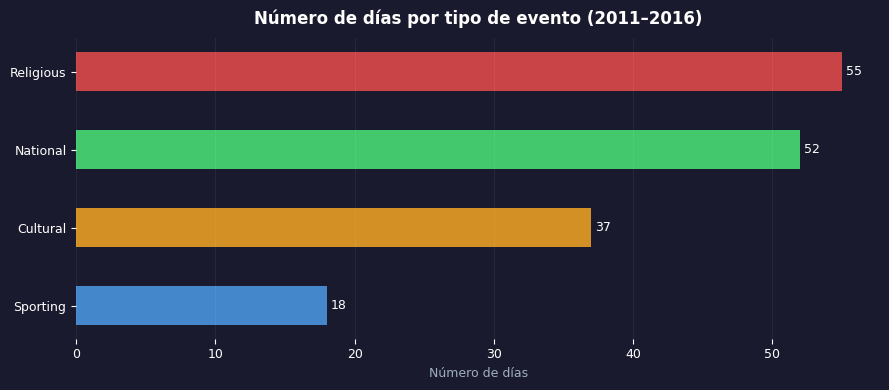

In [43]:
# ── CELDA 24 — gráfica: distribución de eventos por tipo ─────────────────────
 
conteo_eventos = (
    df_calendar[df_calendar["event_type_1"] != "No event"]
    .groupby("event_type_1", observed=True)
    .size()
    .sort_values()
)
 
colores_eventos = ["#4C9BE8", "#F5A623", "#4CE87A", "#E84C4C"]
 
fig, ax = plt.subplots(figsize=(9, 4), facecolor=PALETA["fondo"])
ax.set_facecolor(PALETA["fondo"])
 
barras = ax.barh(
    conteo_eventos.index.astype(str),
    conteo_eventos.values,
    color  = colores_eventos,
    height = 0.5,
    alpha  = 0.85
)
for barra, val in zip(barras, conteo_eventos.values):
    ax.text(val + 0.3, barra.get_y() + barra.get_height() / 2,
            str(val), va="center", fontsize=9, color="white")
 
ax.set_title("Número de días por tipo de evento (2011–2016)", fontsize=12, fontweight="bold", color="white", pad=10)
ax.set_xlabel("Número de días", color=PALETA["neutro"], fontsize=9)
ax.tick_params(colors="white", labelsize=9)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.grid(axis="x", color="white", alpha=0.06)
 
plt.tight_layout()
plt.show()

In [44]:
# ── CELDA 25 — días SNAP por estado ───────────────────────────────────────────
 
print("Días SNAP por estado (sobre el total del período):")
for estado, col in [("California (CA)", "snap_CA"), ("Texas (TX)", "snap_TX"), ("Wisconsin (WI)", "snap_WI")]:
    total_snap = df_calendar[col].sum()
    print(f"  {estado:<20} : {total_snap} días  ({total_snap/len(df_calendar)*100:.1f}%)")
 

Días SNAP por estado (sobre el total del período):
  California (CA)      : 650 días  (33.0%)
  Texas (TX)           : 650 días  (33.0%)
  Wisconsin (WI)       : 650 días  (33.0%)


In [34]:
# ── CELDA 15 — resumen de ceros ───────────────────────────────────────────────
 
total_celdas = df_sales_validation[columnas_dias].size
celdas_cero  = (df_sales_validation[columnas_dias] == 0).sum().sum()
 
print(f"Total de observaciones de venta : {total_celdas:>15,}")
print(f"Celdas con cero                 : {celdas_cero:>15,}  ({celdas_cero / total_celdas * 100:.1f}%)")
print(f"Celdas con venta positiva       : {total_celdas - celdas_cero:>15,}  ({(total_celdas - celdas_cero) / total_celdas * 100:.1f}%)")

Total de observaciones de venta :      58,327,370
Celdas con cero                 :      39,777,094  (68.2%)
Celdas con venta positiva       :      18,550,276  (31.8%)
